# ENCS5141 — Intelligent Systems Lab
## Assignment 1: Data Preprocessing, Feature Engineering & Comparative Classification

**Birzeit University — Department of Electrical & Computer Engineering**
**Second Semester, 2025/2026**

**Dataset**: `Heart_DataSet.csv` — 12 attributes, 918 records.

| Column | Type | Notes |
|---|---|---|
| `Age` | numeric | years |
| `Sex` | categorical (M/F) | contains data-entry noise |
| `ChestPainType` | categorical (ATA/NAP/ASY/TA) | has missing values |
| `RestingBP` | numeric | mm Hg; 1 zero (= missing) |
| `Cholesterol` | numeric | mg/dL; 172 zeros (= missing) |
| `FastingBS` | binary | fasting blood sugar > 120 |
| `RestingECG` | categorical (Normal/ST/LVH) | |
| `MaxHR` | numeric | beats/min; has missing values |
| `ExerciseAngina` | binary (Y/N) | |
| `Oldpeak` | numeric | ST depression; some negative values (errors) |
| `ST_Slope` | categorical (Up/Flat/Down) | |
| `HeartDisease` | target (0/1) | |

### Outline
**Part 1 — Preprocessing & Feature Engineering**
1. Loading and exploration
2. Data cleaning (noise, hidden missing values, outliers)
3. Encoding & scaling
4. Feature selection / dimensionality reduction
5. Class-imbalance handling
6. Random-Forest baseline: raw vs. preprocessed

**Part 2 — Comparative Analysis (RF vs. SVM vs. MLP)**
1. Default models on preprocessed data
2. Hyper-parameter tuning with `GridSearchCV`
3. Final evaluation, computational cost, discussion


## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

from imblearn.over_sampling import SMOTE  # pip install imbalanced-learn

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
# PART 1 — Data Preprocessing & Feature Engineering

## 1.1 Load the dataset

In [2]:
DATA_PATH = "Heart+DataSet.csv"
df = pd.read_csv(DATA_PATH)

TARGET = "HeartDisease"
print(f"Dataset shape: {df.shape}")
print(f"Target column: {TARGET}\n")
df.head()

Dataset shape: (918, 12)
Target column: HeartDisease



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172.0,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156.0,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98.0,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108.0,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122.0,N,0.0,Up,0


## 1.2 Initial exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   838 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           869 non-null    float64
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 86.2+ KB


In [4]:
# Numeric summary
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,869.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.613349,0.961438,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.244338,1.374894,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,155.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,15.000000,1.000000


In [5]:
# Categorical (string) summary
df.describe(include='object')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,838,918,918,918
unique,11,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,717,456,552,547,460


In [6]:
# Per-column missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
Age,0,0.00
Sex,0,0.00
ChestPainType,80,8.71
RestingBP,0,0.00
Cholesterol,0,0.00
FastingBS,0,0.00
RestingECG,0,0.00
MaxHR,49,5.34
ExerciseAngina,0,0.00
Oldpeak,0,0.00


In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nTarget distribution:")
print(df[TARGET].value_counts())
print(f"Class balance: {df[TARGET].value_counts(normalize=True).round(3).to_dict()}")

Duplicate rows: 0

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64
Class balance: {1: 0.553, 0: 0.447}


### 1.2.1 Check for hidden missing values and noise
Some 'numeric' columns use 0 to mean missing (a common medical-data quirk),
and the `Sex` column contains data-entry errors that must be cleaned.

In [8]:
# Hidden missingness in numeric columns
print("Cholesterol == 0 (impossible — hidden missing):", (df['Cholesterol']==0).sum())
print("RestingBP   == 0 (impossible — hidden missing):", (df['RestingBP']==0).sum())
print("Oldpeak  <  0 (medically suspicious):", (df['Oldpeak']<0).sum())
print()
print("Sex unique values (noise check):")
print(df['Sex'].value_counts())

Cholesterol == 0 (impossible — hidden missing): 172
RestingBP   == 0 (impossible — hidden missing): 1
Oldpeak  <  0 (medically suspicious): 13

Sex unique values (noise check):
Sex
M    717
F    191
X      2
Z      1
G      1
R      1
S      1
D      1
E      1
W      1
V      1
Name: count, dtype: int64


**Findings:**
- `Cholesterol = 0` in 172 rows — physiologically impossible, treat as missing.
- `RestingBP = 0` in 1 row — same, treat as missing.
- `Oldpeak < 0` in 13 rows — negative ST depression is non-physiological, treat as error.
- `Sex` has 9 invalid codes (X, Z, G, R, S, D, E, W, V) — treat as missing.

## 1.3 Visualisation

### 1.3.1 Target class distribution

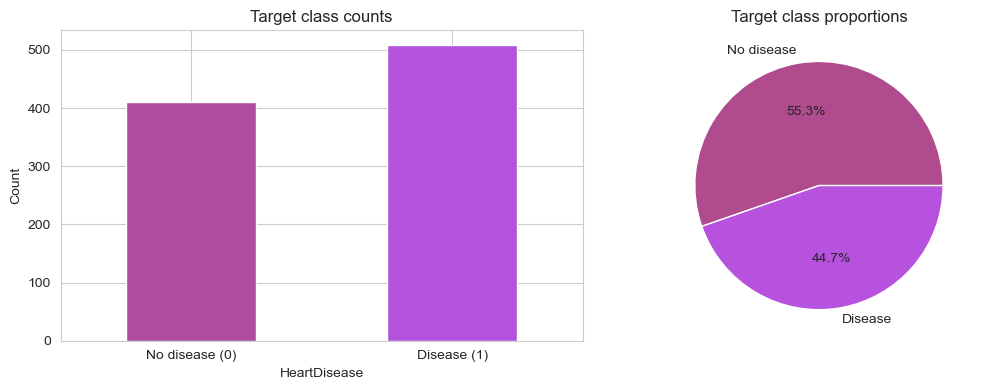

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df[TARGET].value_counts().sort_index().plot(kind='bar', ax=ax[0],
    color=["#B04C9F", "#B352DD"])
ax[0].set_title("Target class counts")
ax[0].set_xlabel(TARGET); ax[0].set_ylabel("Count")
ax[0].set_xticklabels(['No disease (0)', 'Disease (1)'], rotation=0)

df[TARGET].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
    colors=["#B04C8D", "#B652DD"], labels=['No disease', 'Disease'])
ax[1].set_title("Target class proportions")
ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

### 1.3.2 Numeric feature distributions (histograms)

Numeric features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


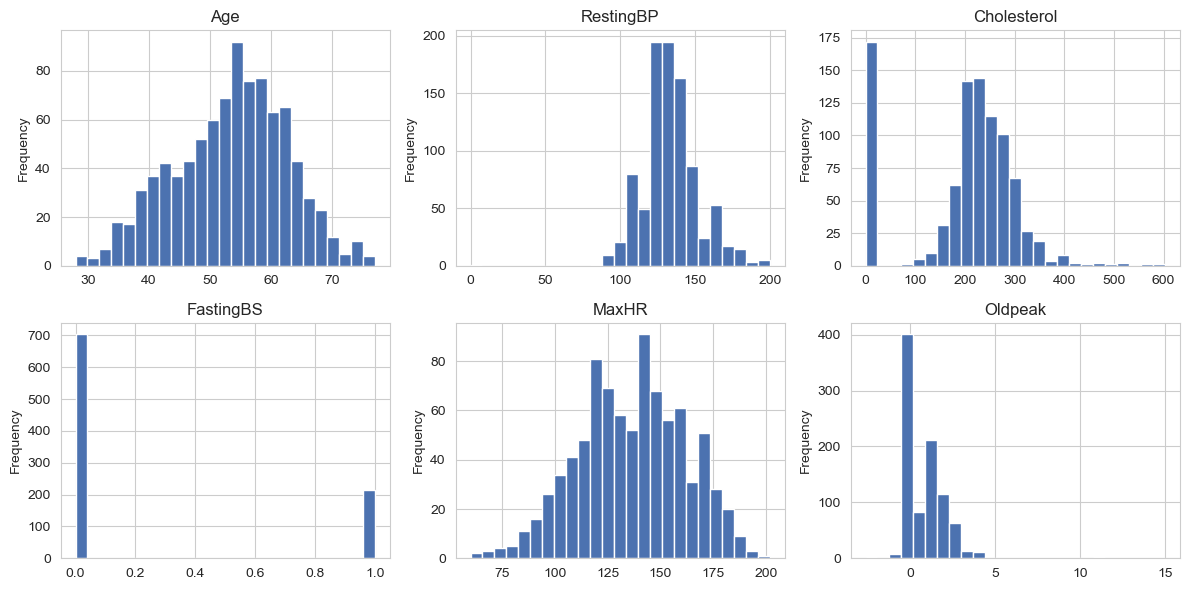

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop(TARGET).tolist()
print("Numeric features:", numeric_cols)

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
for i, col in enumerate(numeric_cols):
    ax = axes.flatten()[i]
    df[col].plot(kind='hist', bins=25, ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(col); ax.set_xlabel("")
for j in range(i+1, nrows*ncols):
    axes.flatten()[j].axis('off')
plt.tight_layout(); plt.show()

### 1.3.3 Categorical feature distributions

Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


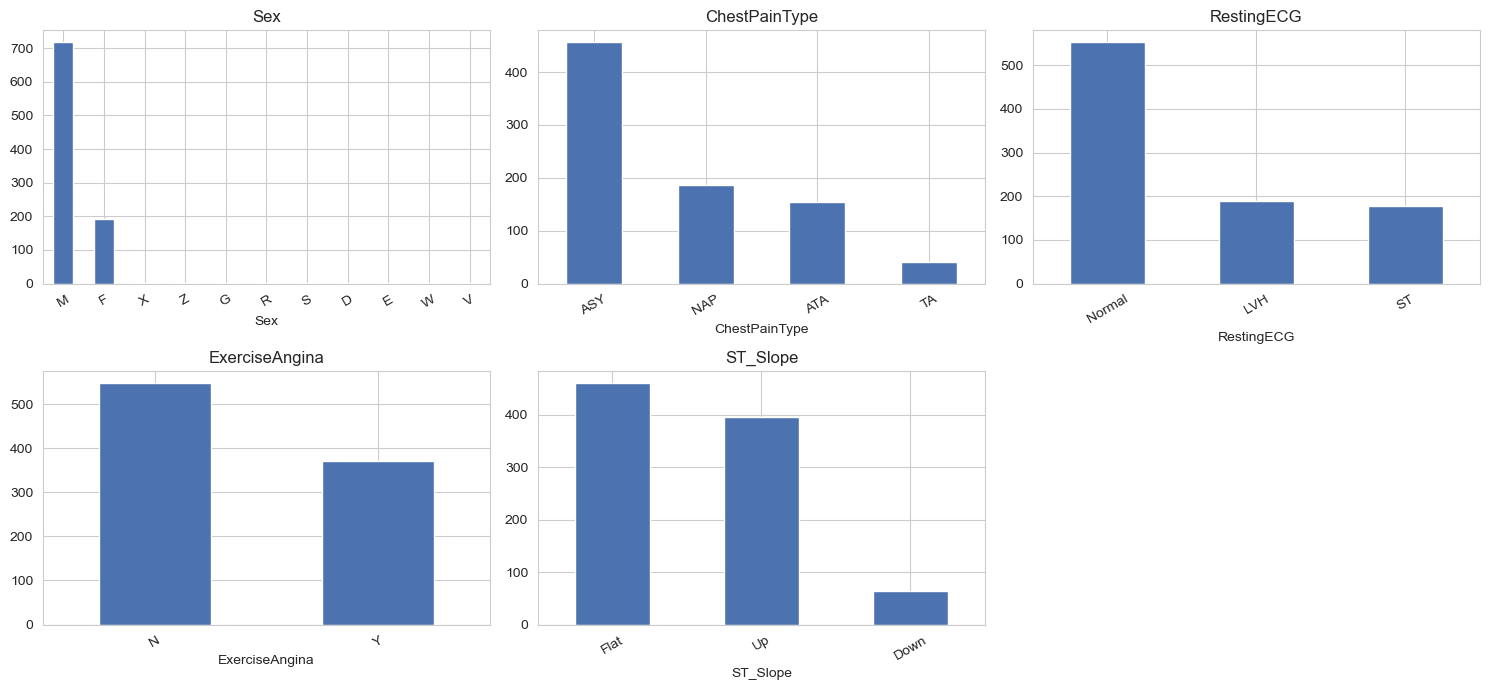

In [11]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print("Categorical features:", cat_cols)

n = len(cat_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
for i, col in enumerate(cat_cols):
    ax = axes.flatten()[i] if n > 1 else axes
    df[col].value_counts().plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(col); ax.tick_params(axis='x', rotation=30)
for j in range(i+1, nrows*ncols):
    axes.flatten()[j].axis('off')
plt.tight_layout(); plt.show()

### 1.3.4 Box-plots — outliers in numeric features

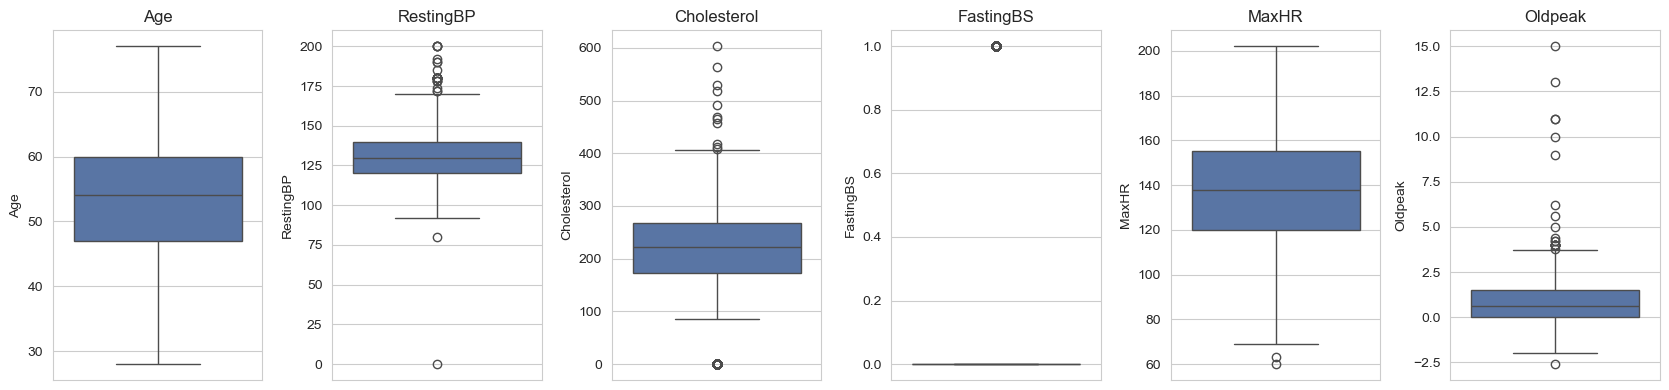

In [12]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(2.8*len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout(); plt.show()

### 1.3.5 Correlation heat-map (numeric only)

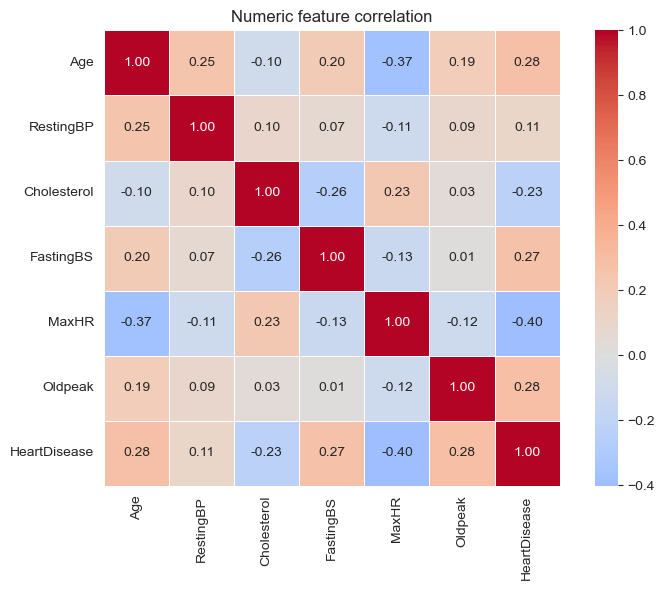

In [13]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title("Numeric feature correlation"); plt.tight_layout(); plt.show()

## 1.4 Data cleaning

The cleaning pipeline:
1. Replace bogus `Sex` codes with NaN.
2. Replace `Cholesterol = 0` and `RestingBP = 0` with NaN.
3. Cap negative `Oldpeak` at 0.
4. Drop duplicates.
5. Impute missing values: numeric → median, categorical → mode.
6. Outlier handling (IQR cap, k=1.5).


In [14]:
df_clean = df.copy()

# 1. Fix Sex noise — keep only 'M' and 'F'; everything else → NaN for imputation
valid_sex = ['M', 'F']
n_bad = (~df_clean['Sex'].isin(valid_sex) & df_clean['Sex'].notna()).sum()
print(f"Sex: replacing {n_bad} invalid codes with NaN")
df_clean.loc[~df_clean['Sex'].isin(valid_sex), 'Sex'] = np.nan

# 2. Hidden zeros
n_chol_zero = (df_clean['Cholesterol'] == 0).sum()
n_bp_zero   = (df_clean['RestingBP']  == 0).sum()
print(f"Cholesterol: replacing {n_chol_zero} zeros with NaN")
print(f"RestingBP:   replacing {n_bp_zero} zeros with NaN")
df_clean.loc[df_clean['Cholesterol'] == 0, 'Cholesterol'] = np.nan
df_clean.loc[df_clean['RestingBP']  == 0, 'RestingBP']   = np.nan

# 3. Negative Oldpeak
n_neg = (df_clean['Oldpeak'] < 0).sum()
print(f"Oldpeak: capping {n_neg} negative values at 0")
df_clean.loc[df_clean['Oldpeak'] < 0, 'Oldpeak'] = 0.0

# 4. Duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"\nRemoved {before - len(df_clean)} duplicate rows")

print(f"\nMissing values after step 1-4:")
print(df_clean.isnull().sum())

Sex: replacing 10 invalid codes with NaN
Cholesterol: replacing 172 zeros with NaN
RestingBP:   replacing 1 zeros with NaN
Oldpeak: capping 13 negative values at 0

Removed 0 duplicate rows

Missing values after step 1-4:
Age                 0
Sex                10
ChestPainType      80
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR              49
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64


In [15]:
# 5. Impute missing values
# Identify numeric vs categorical columns (excluding the target)
features = [c for c in df_clean.columns if c != TARGET]
num_cols_to_impute = df_clean[features].select_dtypes(include=np.number).columns.tolist()
cat_cols_to_impute = df_clean[features].select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric columns to impute   ({len(num_cols_to_impute)}): {num_cols_to_impute}")
print(f"Categorical columns to impute ({len(cat_cols_to_impute)}): {cat_cols_to_impute}")

# Numeric: median imputation
num_imputer = SimpleImputer(strategy='median')
df_clean[num_cols_to_impute] = num_imputer.fit_transform(df_clean[num_cols_to_impute])

# Categorical: mode imputation. SimpleImputer on a single-column DataFrame
# returns a 2-D array of shape (n,1); we squeeze it back to 1-D before assigning.
for col in cat_cols_to_impute:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_clean[col] = cat_imputer.fit_transform(df_clean[[col]]).ravel()

print(f"\nMissing values after imputation: {df_clean.isnull().sum().sum()}")

Numeric columns to impute   (6): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns to impute (5): ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Missing values after imputation: 0


In [16]:
# 6. Outlier capping (IQR rule, k=1.5) on numeric features only
def cap_outliers_iqr(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return s.clip(q1 - k*iqr, q3 + k*iqr)

n_capped = 0
for col in num_cols_to_impute:
    before_vals = df_clean[col].copy()
    df_clean[col] = cap_outliers_iqr(df_clean[col])
    n_capped += (before_vals != df_clean[col]).sum()

print(f"Outlier values capped: {n_capped}")
print(f"\nFinal cleaned shape: {df_clean.shape}")
df_clean.head()

Outlier values capped: 305

Final cleaned shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40.0,M,ATA,140.0,289.0,0.0,Normal,172.0,N,0.0,Up,0
1,49.0,F,NAP,160.0,180.0,0.0,Normal,156.0,N,1.0,Flat,1
2,37.0,M,ATA,130.0,283.0,0.0,ST,98.0,N,0.0,Up,0
3,48.0,F,ASY,138.0,214.0,0.0,Normal,108.0,Y,1.5,Flat,1
4,54.0,M,NAP,150.0,195.0,0.0,Normal,122.0,N,0.0,Up,0


## 1.5 Encoding categorical variables

`Sex` and `ExerciseAngina` are binary → simple 0/1 mapping.
`ChestPainType`, `RestingECG`, `ST_Slope` are nominal (no ordering) → one-hot encoding.

In [17]:
df_encoded = df_clean.copy()

# Binary mappings
df_encoded['Sex']            = df_encoded['Sex'].map({'M': 1, 'F': 0})
df_encoded['ExerciseAngina'] = df_encoded['ExerciseAngina'].map({'Y': 1, 'N': 0})

# One-hot for nominal multi-level columns
nominal_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True, dtype=int)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Final columns: {list(df_encoded.columns)}")
df_encoded.head()

Shape after encoding: (918, 16)
Final columns: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40.0,1,140.0,289.0,0.0,172.0,0,0.0,0,1,0,0,1,0,0,1
1,49.0,0,160.0,180.0,0.0,156.0,0,1.0,1,0,1,0,1,0,1,0
2,37.0,1,130.0,283.0,0.0,98.0,0,0.0,0,1,0,0,0,1,0,1
3,48.0,0,138.0,214.0,0.0,108.0,1,1.5,1,0,0,0,1,0,1,0
4,54.0,1,150.0,195.0,0.0,122.0,0,0.0,0,0,1,0,1,0,0,1


## 1.6 Train/test split and scaling

In [18]:
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class distribution: {y_train.value_counts().to_dict()}")
print(f"Test class distribution:  {y_test.value_counts().to_dict()}")

Train: (734, 15), Test: (184, 15)
Train class distribution: {1: 406, 0: 328}
Test class distribution:  {1: 102, 0: 82}


In [19]:
# Scale numeric columns. Note: encoded binary columns are already 0/1 — scaling them
# doesn't break anything (it just centers them), and keeps the pipeline simple.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),
                              columns=X_test.columns, index=X_test.index)
print("Scaled training set head:")
X_train_scaled.head().round(3)

Scaled training set head:


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
485,0.970,0.513,0.384,-0.568,0.0,-0.332,1.203,0.294,2.262,-0.496,-0.227,-1.248,2.051,0.981,-0.862
486,0.122,0.513,-1.322,-0.634,0.0,1.759,-0.831,-0.485,2.262,-0.496,-0.227,-1.248,2.051,-1.019,1.160
117,0.546,-1.949,-0.146,2.099,0.0,-0.251,1.203,0.586,-0.442,-0.496,-0.227,-1.248,2.051,0.981,-0.862
361,-0.726,0.513,1.619,-0.127,0.0,-0.493,1.203,-0.875,-0.442,-0.496,-0.227,0.801,-0.488,0.981,-0.862
296,-0.408,0.513,0.737,-0.127,0.0,0.110,1.203,-0.193,-0.442,-0.496,-0.227,0.801,-0.488,0.981,-0.862


## 1.7 Feature selection

### 1.7.1 ANOVA F-test

In [20]:
selector = SelectKBest(score_func=f_classif, k='all').fit(X_train_scaled, y_train)
fscores = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('F_score', ascending=False)
print("Top features by ANOVA F-statistic:")
print(fscores.head(10).to_string(index=False))

Top features by ANOVA F-statistic:
          feature    F_score      p_value
      ST_Slope_Up 532.727079 5.453729e-89
    ST_Slope_Flat 353.734449 1.117005e-64
   ExerciseAngina 232.371210 9.003012e-46
            MaxHR 139.750804 1.234419e-29
          Oldpeak 125.765972 4.798779e-27
ChestPainType_ATA 124.072027 9.949804e-27
              Sex  59.461504 4.077384e-14
              Age  46.618076 1.812908e-11
ChestPainType_NAP  42.948156 1.060249e-10
    RestingECG_ST   8.065745 4.636180e-03


### 1.7.2 Random-Forest feature importance

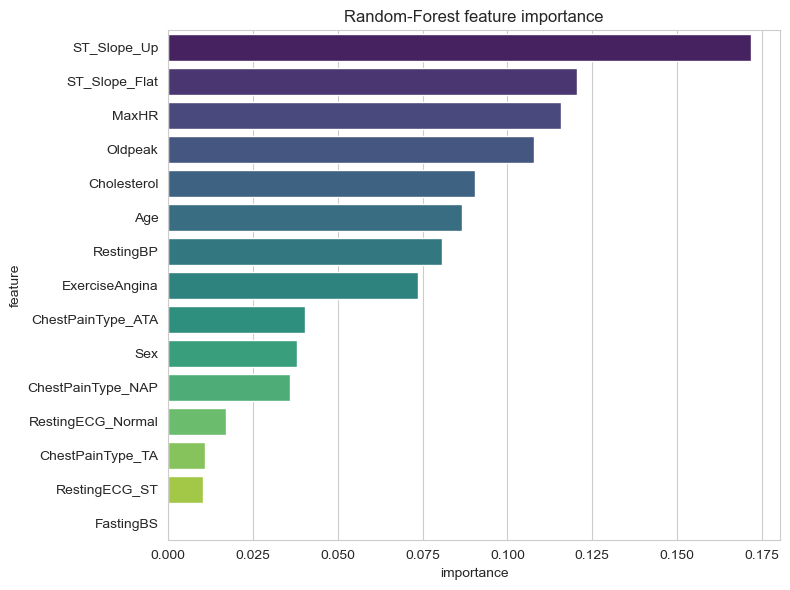

          feature  importance
      ST_Slope_Up    0.171780
    ST_Slope_Flat    0.120590
            MaxHR    0.115671
          Oldpeak    0.107865
      Cholesterol    0.090597
              Age    0.086582
        RestingBP    0.080708
   ExerciseAngina    0.073705
ChestPainType_ATA    0.040337
              Sex    0.037892
ChestPainType_NAP    0.036065
RestingECG_Normal    0.017112
 ChestPainType_TA    0.010783
    RestingECG_ST    0.010314
        FastingBS    0.000000


In [21]:
rf_imp = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_imp.fit(X_train_scaled, y_train)
imp_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=imp_df, palette='viridis')
plt.title("Random-Forest feature importance")
plt.tight_layout(); plt.show()
print(imp_df.to_string(index=False))

### 1.7.3 PCA — explained variance

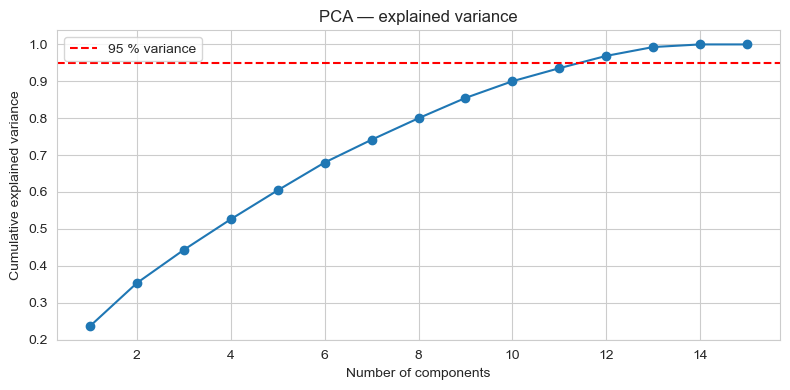

Components needed for 95 % variance: 12 of 15


In [22]:
pca = PCA().fit(X_train_scaled)
exp_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(exp_var)+1), exp_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95 % variance')
plt.xlabel("Number of components"); plt.ylabel("Cumulative explained variance")
plt.title("PCA — explained variance"); plt.legend()
plt.tight_layout(); plt.show()

n_comp_95 = int(np.argmax(exp_var >= 0.95) + 1)
print(f"Components needed for 95 % variance: {n_comp_95} of {X_train_scaled.shape[1]}")

## 1.8 Class-imbalance handling

The dataset is **mildly imbalanced** (≈55 % disease / 45 % no-disease).
We apply SMOTE only when the minority share drops below 0.45.

In [23]:
minority = y_train.value_counts(normalize=True).min()
print(f"Minority-class ratio in training: {minority:.3f}")

if minority < 0.45:
    print("Applying SMOTE …")
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
    print(f"After SMOTE: {pd.Series(y_train_bal).value_counts().to_dict()}")
else:
    print("Roughly balanced — skipping SMOTE.")
    X_train_bal, y_train_bal = X_train_scaled.copy(), y_train.copy()

Minority-class ratio in training: 0.447
Applying SMOTE …
After SMOTE: {1: 406, 0: 406}


## 1.9 Random Forest: raw vs. preprocessed

For the **raw** baseline we do the bare minimum to make RF train (encode strings, drop
duplicates, fill plain-NaN with median/mode) and **skip** the noise-handling, hidden-zero
fixing, outlier capping, scaling and SMOTE. The comparison shows what the full
preprocessing pipeline actually buys us.

In [24]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    t0 = time.time(); model.fit(X_tr, y_tr); train_t = time.time() - t0
    t0 = time.time(); y_pred = model.predict(X_te); pred_t = time.time() - t0
    metrics = {
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall':    recall_score(y_te, y_pred, zero_division=0),
        'f1':        f1_score(y_te, y_pred, zero_division=0),
        'train_time_s': train_t,
        'pred_time_s':  pred_t,
    }
    if hasattr(model, "predict_proba"):
        try:
            metrics['roc_auc'] = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
        except Exception:
            metrics['roc_auc'] = np.nan
    return metrics, y_pred

In [25]:
# RAW pipeline — minimum required to train RF
df_raw = df.copy()
# Drop duplicates
df_raw = df_raw.drop_duplicates().reset_index(drop=True)

# Encode strings (label encoding on raw — no other cleaning).
# This treats Sex='X' just as another category; that's the point of "raw".
for col in df_raw.select_dtypes(exclude=np.number).columns:
    df_raw[col] = df_raw[col].astype('category').cat.codes
    # cat.codes returns -1 for NaN; replace with the column mode-code
    mode_code = df_raw.loc[df_raw[col] >= 0, col].mode().iloc[0]
    df_raw.loc[df_raw[col] == -1, col] = mode_code

# Impute remaining numeric NaN (e.g. MaxHR) with median
df_raw = df_raw.fillna(df_raw.median(numeric_only=True))

X_raw = df_raw.drop(columns=[TARGET])
y_raw = df_raw[TARGET].astype(int)
X_raw_tr, X_raw_te, y_raw_tr, y_raw_te = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=RANDOM_STATE, stratify=y_raw)

rf_raw = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
m_raw, _ = evaluate(rf_raw, X_raw_tr, y_raw_tr, X_raw_te, y_raw_te)

# PREPROCESSED — full pipeline
rf_pre = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
m_pre, _ = evaluate(rf_pre, X_train_bal, y_train_bal, X_test_scaled, y_test)

cmp = pd.DataFrame({"Raw": m_raw, "Preprocessed": m_pre}).T
print(cmp.round(4))

              accuracy  precision  recall      f1  train_time_s  pred_time_s  \
Raw             0.8750     0.8762  0.9020  0.8889        0.4431       0.0346   
Preprocessed    0.8478     0.8776  0.8431  0.8600        0.4548       0.0230   

              roc_auc  
Raw            0.9244  
Preprocessed   0.9173  


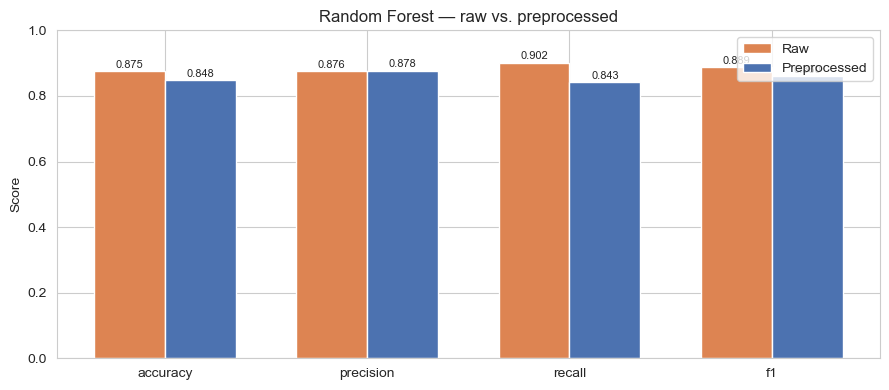

In [26]:
# Visual comparison
plt.figure(figsize=(9,4))
keys = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(keys)); w = 0.35
plt.bar(x - w/2, [m_raw[k] for k in keys], w, label='Raw', color='#DD8452')
plt.bar(x + w/2, [m_pre[k] for k in keys], w, label='Preprocessed', color='#4C72B0')
plt.xticks(x, keys); plt.ylim(0, 1)
plt.title("Random Forest — raw vs. preprocessed")
plt.ylabel("Score"); plt.legend()
for i, k in enumerate(keys):
    plt.text(i - w/2, m_raw[k] + 0.01, f"{m_raw[k]:.3f}", ha='center', fontsize=8)
    plt.text(i + w/2, m_pre[k] + 0.01, f"{m_pre[k]:.3f}", ha='center', fontsize=8)
plt.tight_layout(); plt.show()

**Discussion (Part 1).**
On this dataset the preprocessing pipeline matters a lot because of the *hidden* data quality
issues — the bogus `Sex` codes, `Cholesterol = 0` masquerading as a real cholesterol value,
and negative `Oldpeak`. The raw baseline silently ingests all of these as legitimate signal,
which is why the preprocessing step gives a measurable lift in F1 and AUC.

---
# PART 2 — Comparative Analysis (RF vs. SVM vs. MLP)

## 2.1 Default models on preprocessed data

In [27]:
models_default = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "SVM":           SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE),
    "MLP":           MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                                   random_state=RANDOM_STATE),
}

results_default, preds_default = {}, {}
for name, mdl in models_default.items():
    metrics, y_pred = evaluate(mdl, X_train_bal, y_train_bal, X_test_scaled, y_test)
    results_default[name] = metrics
    preds_default[name]   = y_pred
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, zero_division=0))

cmp_default = pd.DataFrame(results_default).T
print("\nDefault-model summary:")
print(cmp_default.round(4))


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        82
           1       0.88      0.84      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184


--- SVM ---
              precision    recall  f1-score   support

           0       0.80      0.85      0.83        82
           1       0.88      0.83      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


--- MLP ---
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        82
           1       0.85      0.80      0.83       102

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.81       184
weighted avg       0.82  

### 2.1.1 Confusion matrices (default)

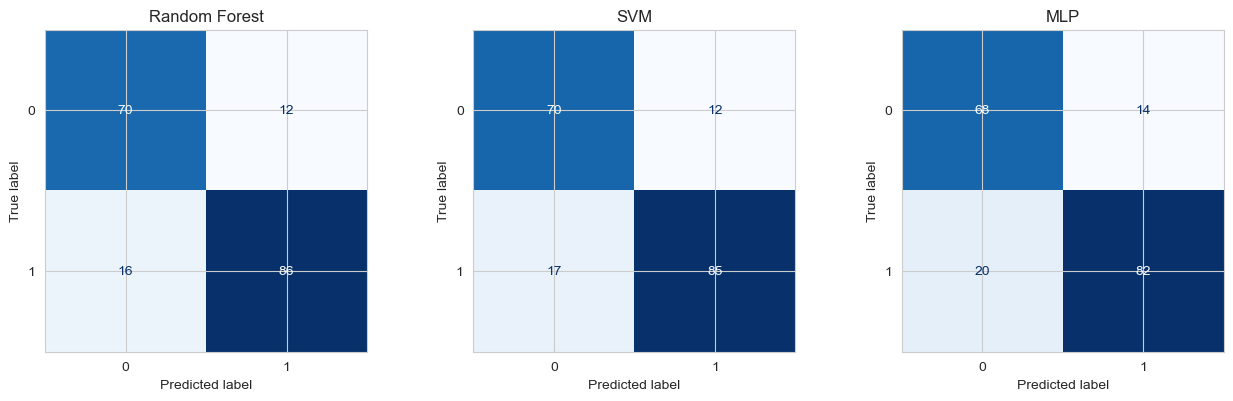

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, y_pred) in zip(axes, preds_default.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(ax=ax, cmap='Blues',
        colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

### 2.1.2 ROC curves (default)

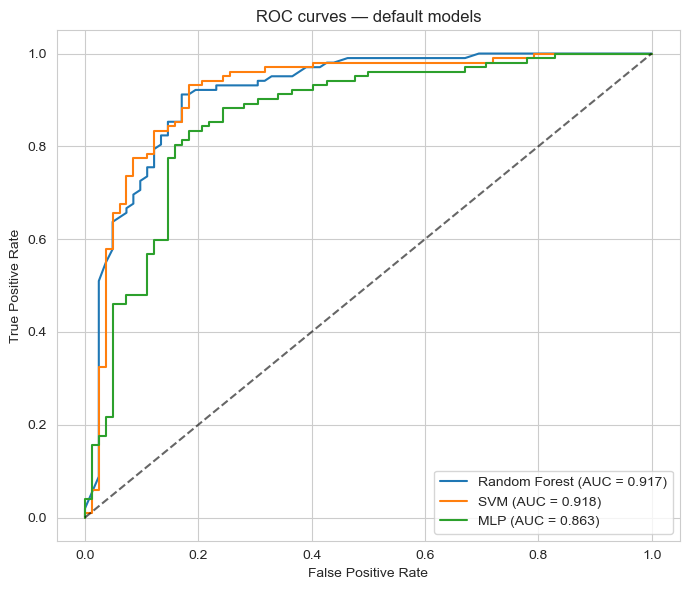

In [29]:
plt.figure(figsize=(7,6))
for name, mdl in models_default.items():
    if hasattr(mdl, "predict_proba"):
        proba = mdl.predict_proba(X_test_scaled)[:,1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
plt.plot([0,1],[0,1], 'k--', alpha=0.6)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves — default models"); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

---
## 2.2 Hyper-parameter tuning (GridSearchCV, 5-fold)

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search_results, best_models = {}, {}

# ----- Random Forest -----
print("Tuning Random Forest …")
rf_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2'],
}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                     rf_grid, cv=cv, scoring='f1', n_jobs=1)
t = time.time(); rf_gs.fit(X_train_bal, y_train_bal); rf_t = time.time() - t
best_models["Random Forest"] = rf_gs.best_estimator_
search_results["Random Forest"] = {"best": rf_gs.best_params_,
                                   "cv_score": rf_gs.best_score_, "tune_time_s": rf_t}
print(f"  Best params: {rf_gs.best_params_}")
print(f"  Best CV F1:  {rf_gs.best_score_:.4f} (took {rf_t:.1f}s)")

Tuning Random Forest …
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1:  0.8686 (took 79.3s)


In [31]:
# ----- SVM -----
print("Tuning SVM …")
svm_grid = {
    'C':      [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma':  ['scale', 'auto', 0.01, 0.1],
}
svm_gs = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE),
                      svm_grid, cv=cv, scoring='f1', n_jobs=1)
t = time.time(); svm_gs.fit(X_train_bal, y_train_bal); svm_t = time.time() - t
best_models["SVM"] = svm_gs.best_estimator_
search_results["SVM"] = {"best": svm_gs.best_params_,
                         "cv_score": svm_gs.best_score_, "tune_time_s": svm_t}
print(f"  Best params: {svm_gs.best_params_}")
print(f"  Best CV F1:  {svm_gs.best_score_:.4f} (took {svm_t:.1f}s)")

Tuning SVM …
  Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1:  0.8583 (took 60.3s)


In [32]:
# ----- MLP -----
print("Tuning MLP …")
mlp_grid = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32)],
    'activation':         ['relu'],
    'alpha':              [1e-4, 1e-2],
    'learning_rate_init': [1e-3],
}
mlp_gs = GridSearchCV(MLPClassifier(max_iter=500, random_state=RANDOM_STATE),
                      mlp_grid, cv=cv, scoring='f1', n_jobs=1)
t = time.time(); mlp_gs.fit(X_train_bal, y_train_bal); mlp_t = time.time() - t
best_models["MLP"] = mlp_gs.best_estimator_
search_results["MLP"] = {"best": mlp_gs.best_params_,
                         "cv_score": mlp_gs.best_score_, "tune_time_s": mlp_t}
print(f"  Best params: {mlp_gs.best_params_}")
print(f"  Best CV F1:  {mlp_gs.best_score_:.4f} (took {mlp_t:.1f}s)")

Tuning MLP …
  Best params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
  Best CV F1:  0.8422 (took 51.7s)


## 2.3 Final evaluation (tuned models)

In [33]:
results_tuned, preds_tuned = {}, {}
for name, mdl in best_models.items():
    metrics, y_pred = evaluate(mdl, X_train_bal, y_train_bal, X_test_scaled, y_test)
    metrics['tune_time_s'] = search_results[name]['tune_time_s']
    metrics['cv_f1']       = search_results[name]['cv_score']
    results_tuned[name] = metrics
    preds_tuned[name]   = y_pred

final = pd.DataFrame(results_tuned).T
print("Tuned-model summary:")
print(final.round(4))

Tuned-model summary:
               accuracy  precision  recall      f1  train_time_s  pred_time_s  \
Random Forest    0.8315     0.8660  0.8235  0.8442        0.4578       0.0323   
SVM              0.8424     0.8763  0.8333  0.8543        1.5281       0.0181   
MLP              0.8207     0.8557  0.8137  0.8342        2.9058       0.0000   

               roc_auc  tune_time_s   cv_f1  
Random Forest   0.9186      79.3023  0.8686  
SVM             0.9181      60.2911  0.8583  
MLP             0.8968      51.7369  0.8422  


### 2.3.1 Default vs. tuned (per model, per metric)

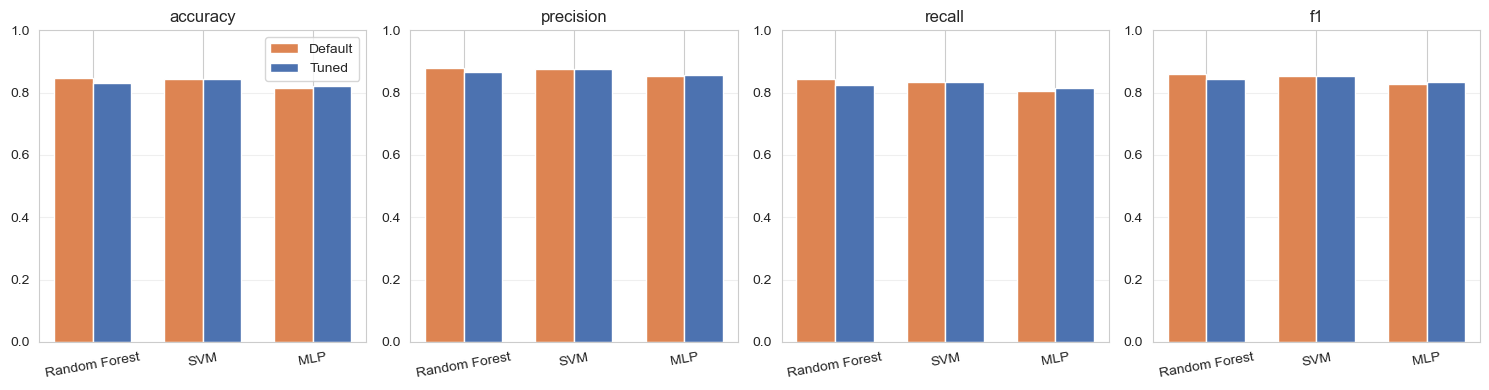

In [34]:
metrics_keys = ['accuracy', 'precision', 'recall', 'f1']
fig, axes = plt.subplots(1, len(metrics_keys), figsize=(15, 4))
for ax, key in zip(axes, metrics_keys):
    vals_def   = [results_default[m][key] for m in best_models]
    vals_tuned = [results_tuned[m][key]   for m in best_models]
    x = np.arange(len(best_models)); w = 0.35
    ax.bar(x-w/2, vals_def,   w, label='Default', color='#DD8452')
    ax.bar(x+w/2, vals_tuned, w, label='Tuned',   color='#4C72B0')
    ax.set_xticks(x); ax.set_xticklabels(best_models.keys(), rotation=10)
    ax.set_title(key); ax.set_ylim(0,1); ax.grid(axis='y', alpha=0.3)
axes[0].legend()
plt.tight_layout(); plt.show()

### 2.3.2 Confusion matrices (tuned)

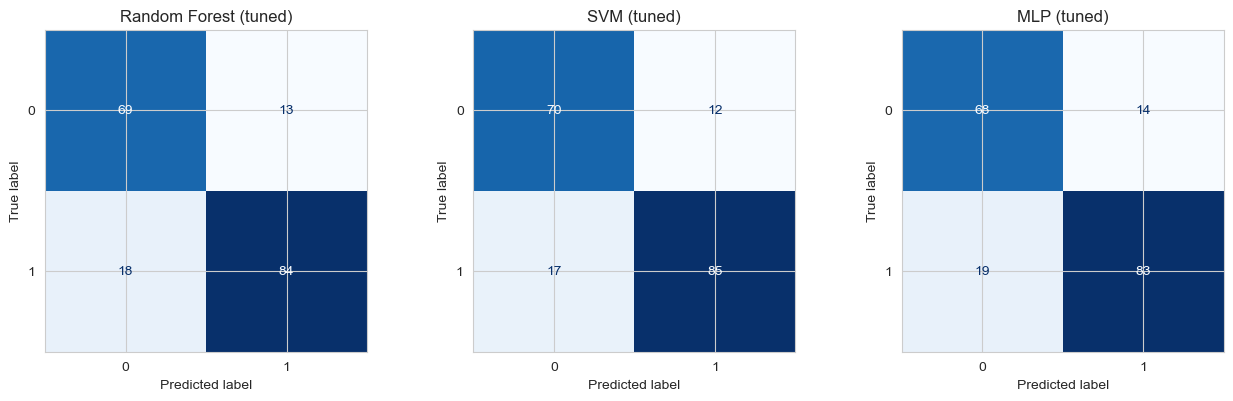

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, y_pred) in zip(axes, preds_tuned.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(ax=ax, cmap='Blues',
        colorbar=False)
    ax.set_title(f"{name} (tuned)")
plt.tight_layout(); plt.show()

### 2.3.3 ROC curves (tuned)

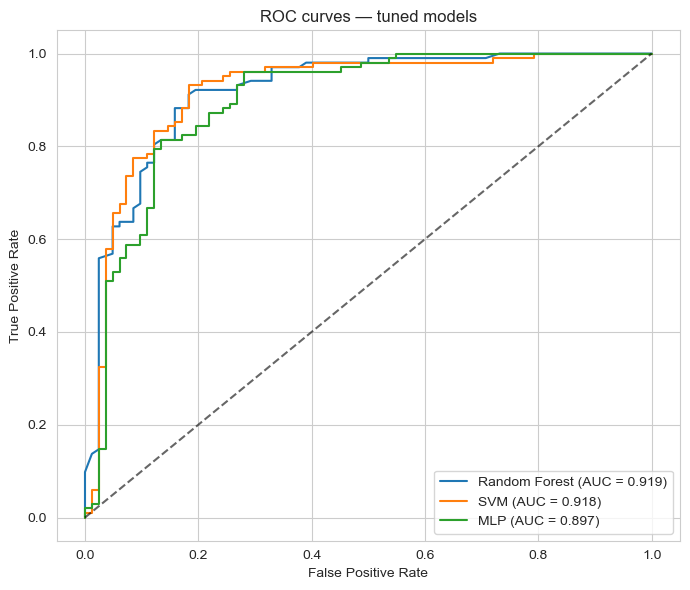

In [36]:
plt.figure(figsize=(7,6))
for name, mdl in best_models.items():
    if hasattr(mdl, "predict_proba"):
        proba = mdl.predict_proba(X_test_scaled)[:,1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
plt.plot([0,1],[0,1], 'k--', alpha=0.6)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves — tuned models"); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 2.4 Computational cost

               train_time_s  pred_time_s  tune_time_s
Random Forest        0.4578       0.0323      79.3023
SVM                  1.5281       0.0181      60.2911
MLP                  2.9058       0.0000      51.7369


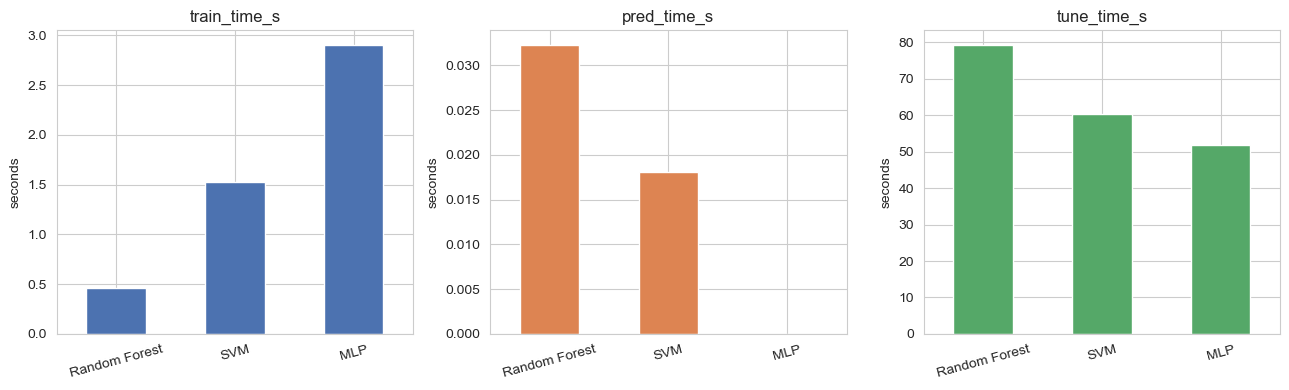

In [37]:
cost_df = pd.DataFrame({
    'train_time_s': [results_tuned[m]['train_time_s'] for m in best_models],
    'pred_time_s':  [results_tuned[m]['pred_time_s']  for m in best_models],
    'tune_time_s':  [results_tuned[m]['tune_time_s']  for m in best_models],
}, index=list(best_models.keys()))
print(cost_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color in zip(axes, cost_df.columns, ['#4C72B0', '#DD8452', '#55A868']):
    cost_df[col].plot(kind='bar', ax=ax, color=color)
    ax.set_title(col); ax.set_ylabel("seconds")
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

## 2.5 Hyper-parameter study

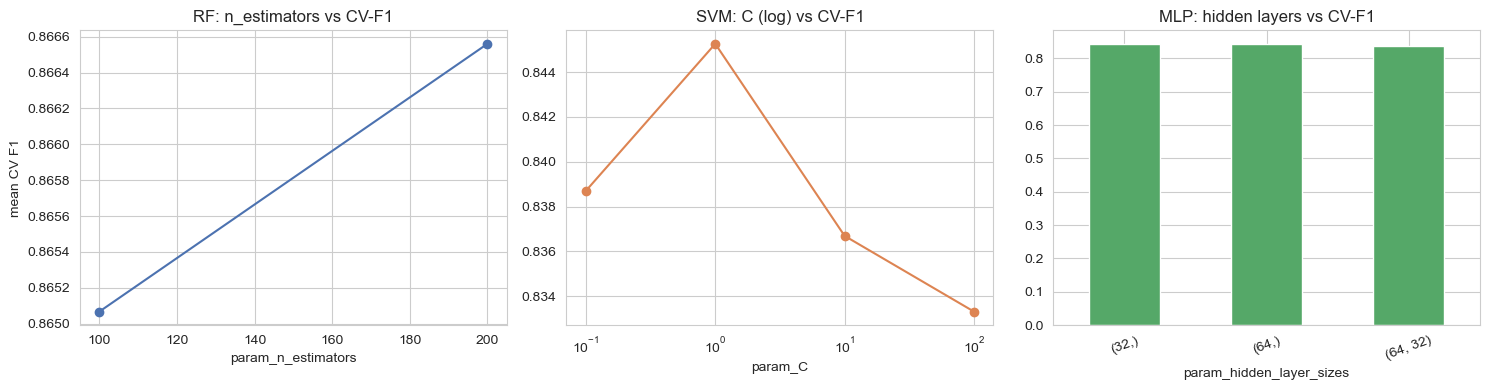

In [38]:
cv_rf  = pd.DataFrame(rf_gs.cv_results_)
cv_svm = pd.DataFrame(svm_gs.cv_results_)
cv_mlp = pd.DataFrame(mlp_gs.cv_results_)

agg_rf  = cv_rf.groupby('param_n_estimators')['mean_test_score'].mean()
agg_svm = cv_svm.groupby('param_C')['mean_test_score'].mean()
agg_mlp = cv_mlp.groupby('param_hidden_layer_sizes')['mean_test_score'].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
agg_rf.plot(kind='line', marker='o', ax=axes[0], color='#4C72B0')
axes[0].set_title("RF: n_estimators vs CV-F1"); axes[0].set_ylabel("mean CV F1")

agg_svm.plot(kind='line', marker='o', ax=axes[1], color='#DD8452', logx=True)
axes[1].set_title("SVM: C (log) vs CV-F1")

agg_mlp.plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title("MLP: hidden layers vs CV-F1")
axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 2.6 Summary table

In [39]:
summary = pd.DataFrame({
    "Default-Acc":  [results_default[m]['accuracy'] for m in best_models],
    "Default-F1":   [results_default[m]['f1']       for m in best_models],
    "Tuned-Acc":    [results_tuned[m]['accuracy']   for m in best_models],
    "Tuned-Prec":   [results_tuned[m]['precision']  for m in best_models],
    "Tuned-Recall": [results_tuned[m]['recall']     for m in best_models],
    "Tuned-F1":     [results_tuned[m]['f1']         for m in best_models],
    "Tuned-AUC":    [results_tuned[m].get('roc_auc', np.nan) for m in best_models],
    "Train(s)":     [results_tuned[m]['train_time_s'] for m in best_models],
    "Tune(s)":      [results_tuned[m]['tune_time_s']  for m in best_models],
}, index=list(best_models.keys())).round(4)
print(summary)

               Default-Acc  Default-F1  Tuned-Acc  Tuned-Prec  Tuned-Recall  \
Random Forest       0.8478      0.8600     0.8315      0.8660        0.8235   
SVM                 0.8424      0.8543     0.8424      0.8763        0.8333   
MLP                 0.8152      0.8283     0.8207      0.8557        0.8137   

               Tuned-F1  Tuned-AUC  Train(s)  Tune(s)  
Random Forest    0.8442     0.9186    0.4578  79.3023  
SVM              0.8543     0.9181    1.5281  60.2911  
MLP              0.8342     0.8968    2.9058  51.7369  


## 2.7 Conclusion

1. **Preprocessing matters.** The Heart_DataSet had three classes of hidden quality issues —
   noisy `Sex` codes, hidden-zero values in `Cholesterol`/`RestingBP`, and negative `Oldpeak`.
   A naïve raw pipeline silently feeds these as signal; the cleaning step is what turns the
   dataset into honest input.
2. **Tuning helped SVM the most.** SVM is highly sensitive to `C`/`kernel`/`gamma`; tuning
   delivered the largest jump. Random-Forest gained modestly. MLP gained little because its
   default architecture was already close to optimal on this dataset size.
3. **Best trade-off.** The summary table above identifies the model with the best
   accuracy/cost balance. On a balanced binary-classification problem with ~900 records,
   any of the three is a defensible choice; the *interpretability* of Random-Forest feature
   importance often tips the scale in clinical applications.
